# O-Level Mathematics Score Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the dataset
df = pd.read_csv("data/regression_bonus_practice_data.csv")
df.head()

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,NaN,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  str    
 3   CCA                 12071 non-null  str    
 4   learning_style      15900 non-null  str    
 5   student_id          15900 non-null  str    
 6   gender              15900 non-null  str    
 7   tuition             15900 non-null  str    
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  str    
 15  wake_time           15900 non-null  str    
 16  mode_of_transpo

In [4]:
#Checking for missing values in the dataset
df.isnull().sum()

index                    0
number_of_siblings       0
direct_admission         0
CCA                   3829
learning_style           0
student_id               0
gender                   0
tuition                  0
final_test             495
n_male                   0
n_female                 0
age                      0
hours_per_week           0
attendance_rate        778
sleep_time               0
wake_time                0
mode_of_transport        0
bag_color                0
dtype: int64

In [5]:
#Dealing with missing values in the dataset
df["CCA"] = df["CCA"].fillna("NONE")
df = df.dropna(subset=["final_test"])

median_attendance = df["attendance_rate"].median()
print(median_attendance)
df["attendance_rate"] = df["attendance_rate"].fillna(median_attendance)

95.0


In [6]:
#Checking for missing values in the dataset after handling them
df.isnull().sum()

index                 0
number_of_siblings    0
direct_admission      0
CCA                   0
learning_style        0
student_id            0
gender                0
tuition               0
final_test            0
n_male                0
n_female              0
age                   0
hours_per_week        0
attendance_rate       0
sleep_time            0
wake_time             0
mode_of_transport     0
bag_color             0
dtype: int64

### Missing Value Treatment

**CCA:**
Empty values in the CCA column are assumed to indicate that the student did not participate in any CCA. Therefore, the missing values are treated as a separate category, "None", rather than being removed or imputed.

**Final Test Score:**
Rows without a final test score are removed because the final test score is the target variable that the model is required to predict. Since the actual target value is unavailable, these rows cannot be used to train or evaluate the regression models. Imputing the final test score could also introduce artificial target values and affect the model's performance.

**Attendance Rate:**
Missing values in the attendance rate column are replaced using the median attendance rate calculated from the available observations. Median imputation is used because it is less affected by extreme values than the mean. This approach also allows the affected student records to be retained rather than removing entire rows from the dataset.


In [7]:
#Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

### Duplicate Treatment

The dataset was checked for duplicate rows, and no duplicate records were found. Therefore, no further action is required for duplicate data.

In [8]:
# checking for negative values in the dataset
negative_counts = (df.select_dtypes(include="number") < 0).sum()

print(negative_counts)

index                 0
number_of_siblings    0
final_test            0
n_male                0
n_female              0
age                   5
hours_per_week        0
attendance_rate       0
dtype: int64


In [9]:
#See the actual rows containing negative values
negative_rows = df[
    df.select_dtypes(include="number").lt(0).any(axis=1)
]

negative_rows

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
4513,4513,2,No,Sports,Auditory,RXTBXJ,Male,No,48.0,15.0,4.0,-4.0,2.0,94.0,21:30,5:30,public transport,red
7932,7932,1,No,Sports,Auditory,UAMI3G,Female,No,52.0,3.0,26.0,-5.0,13.0,92.0,21:00,5:00,public transport,yellow
8602,8602,0,No,NONE,Visual,XQMSBU,Female,No,67.0,10.0,18.0,-5.0,18.0,91.0,22:00,6:00,private transport,green
8663,8663,0,Yes,Arts,Visual,39XWY2,Male,Yes,85.0,17.0,3.0,-5.0,5.0,94.0,23:00,7:00,walk,blue
8846,8846,2,No,Sports,Auditory,Z33FOS,Female,Yes,74.0,4.0,19.0,-5.0,13.0,90.0,22:00,6:00,private transport,white


In [10]:
#Finding the median age
median_age = round(df["age"].median())
print(median_age)

15


In [11]:
# Handle invalid negative age
df.loc[df["age"] < 0, "age"] = median_age

In [12]:
# checking for negative values under age column after handling
print(df["age"].value_counts().sort_index())

age
5.0      206
6.0      225
15.0    7488
16.0    7486
Name: count, dtype: int64


In [13]:
#replace wrong values with median age

df.loc[df["age"] < 15, "age"] = median_age

In [14]:
# checking for negative values under age column after handling
print(df["age"].value_counts().sort_index())

age
15.0    7919
16.0    7486
Name: count, dtype: int64


The age column contained invalid values, including negative ages and ages of 5 or 6 years old. Since the dataset represents students taking O-level Mathematics, these values are considered implausible for the target population and were treated as missing values. The invalid ages were subsequently imputed using the median age calculated from the valid observations, rounded to the nearest whole number.


In [15]:
#Standardising Tuition Data
df["tuition"] = df["tuition"].replace({
    "Y": "Yes",
    "N": "No"
})

In [16]:
#dropping unnecessary columns
df.drop(columns=["student_id", "bag_color"], inplace=True)

In [17]:
#Visualze the dropping of unnecessary columns
df.head()

,index,number_of_siblings,direct_admission,CCA,learning_style,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport
0,0,0,Yes,Sports,Visual,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport
1,1,2,No,Sports,Auditory,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport
2,2,0,Yes,NONE,Visual,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport
3,3,1,No,Clubs,Auditory,Female,Yes,64.0,2.0,20.0,15.0,18.0,95.0,21:00,5:00,public transport
4,4,0,No,Sports,Auditory,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport


### Dropping Unnecessary Columns

* **`student_id`** was dropped because it is an identifier for individual students and does not provide meaningful information for predicting the mathematics score.

* **`bag_color`** was dropped because it does not provide meaningful predictive information for the mathematics score and is therefore not necessary for the model.


### Visualizing data

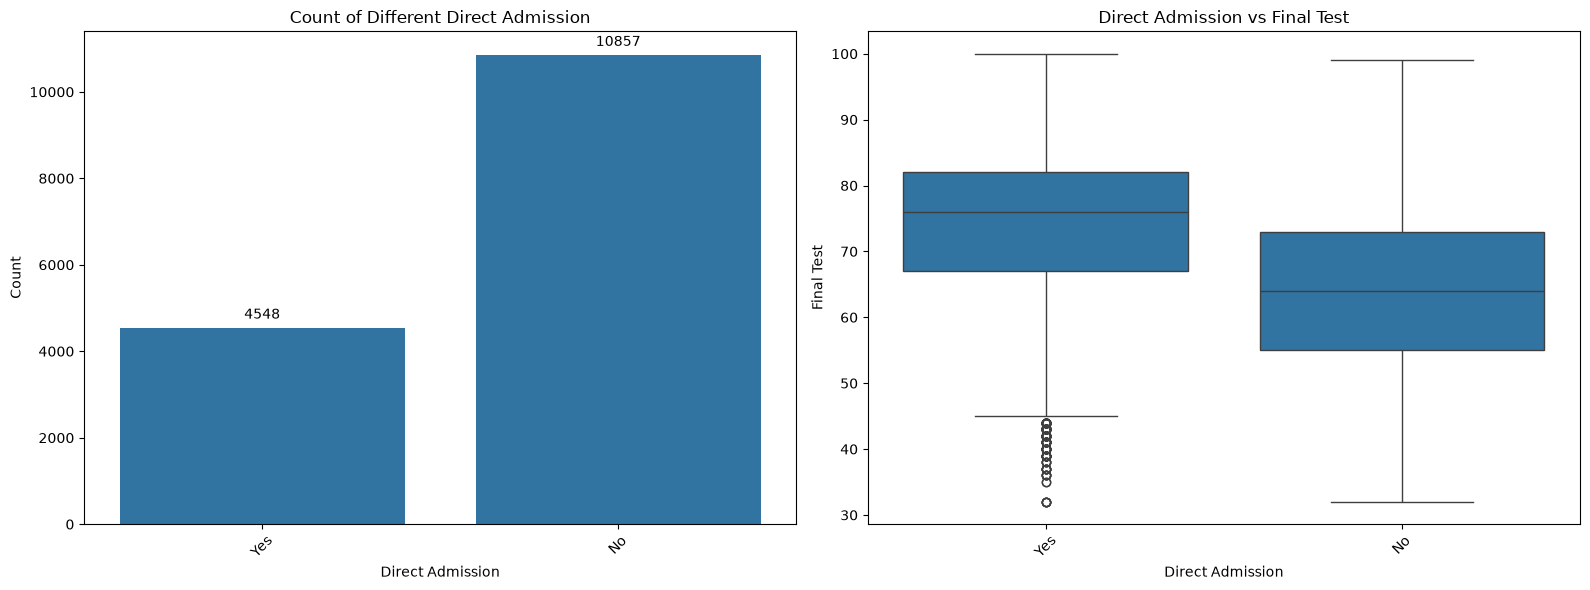

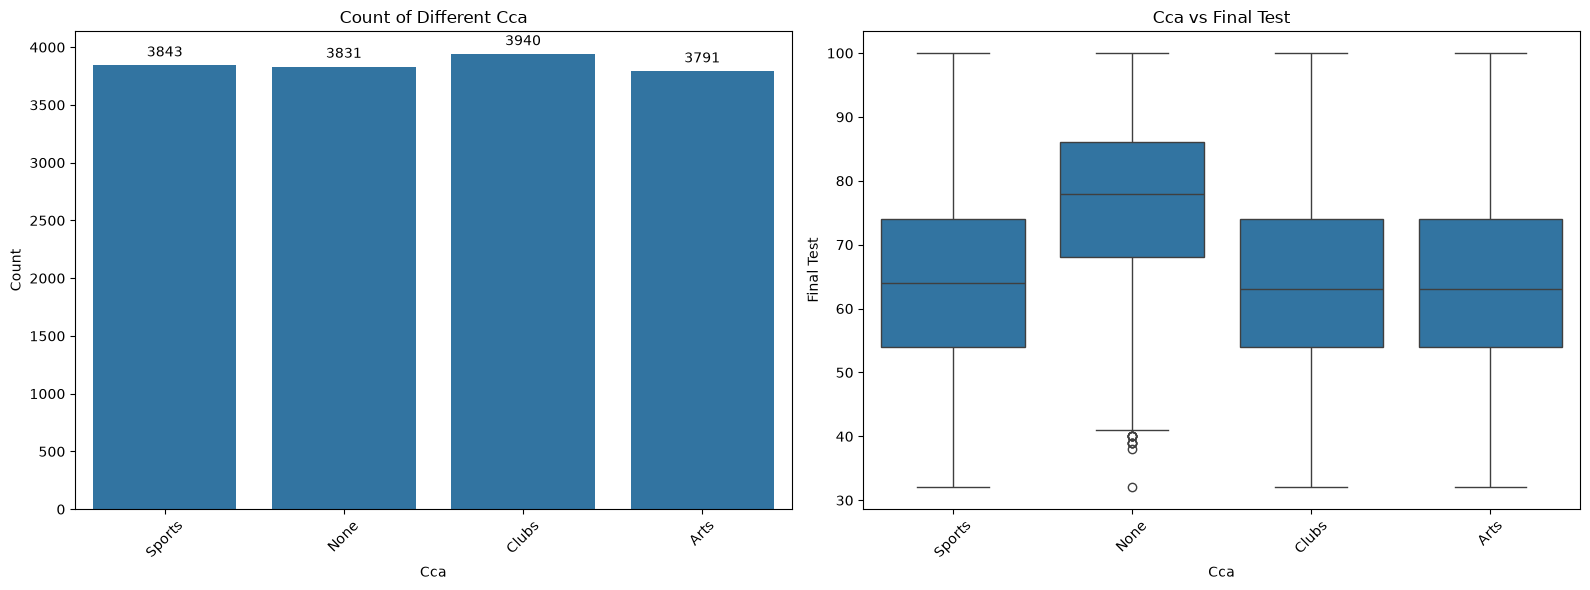

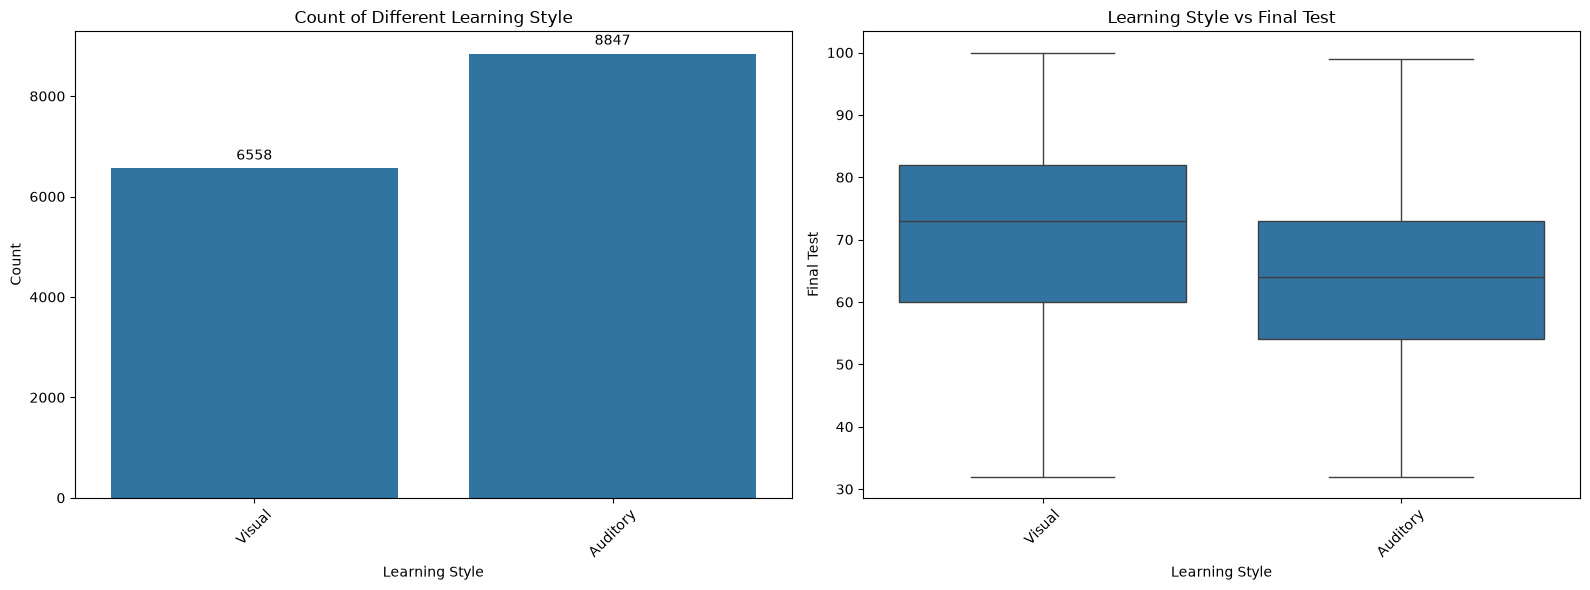

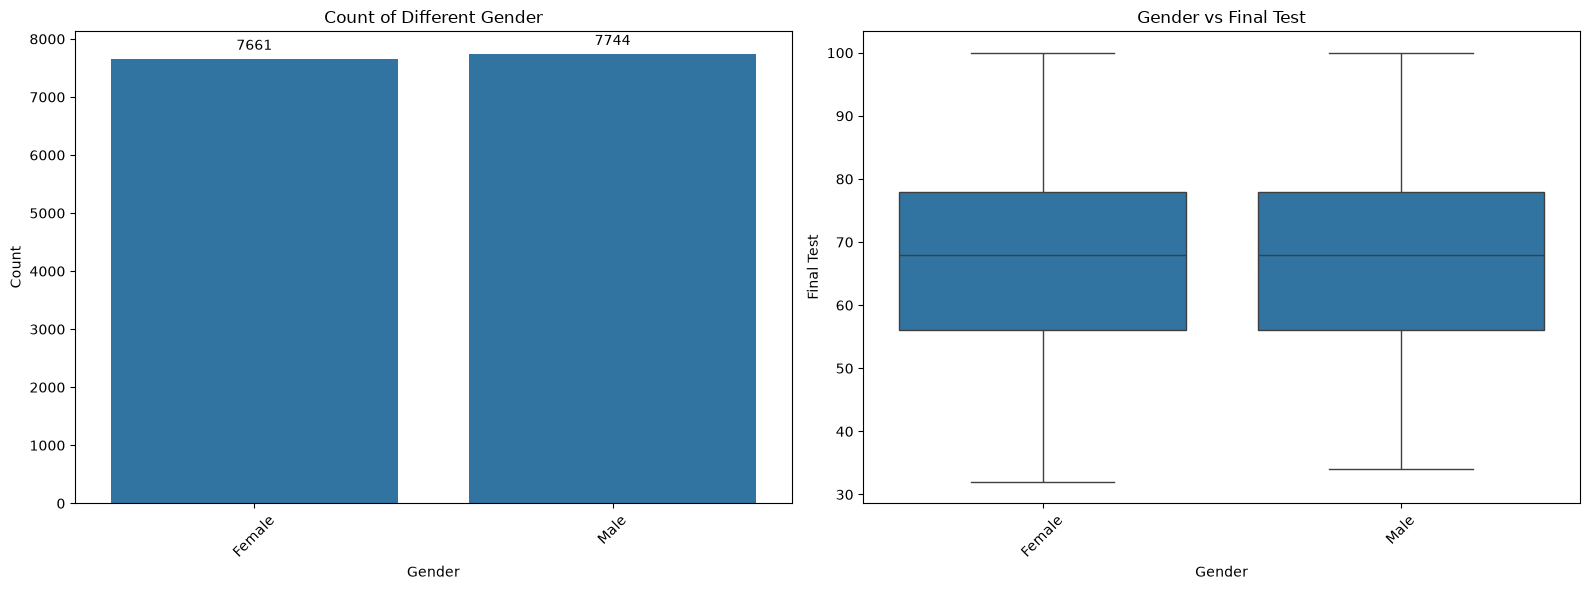

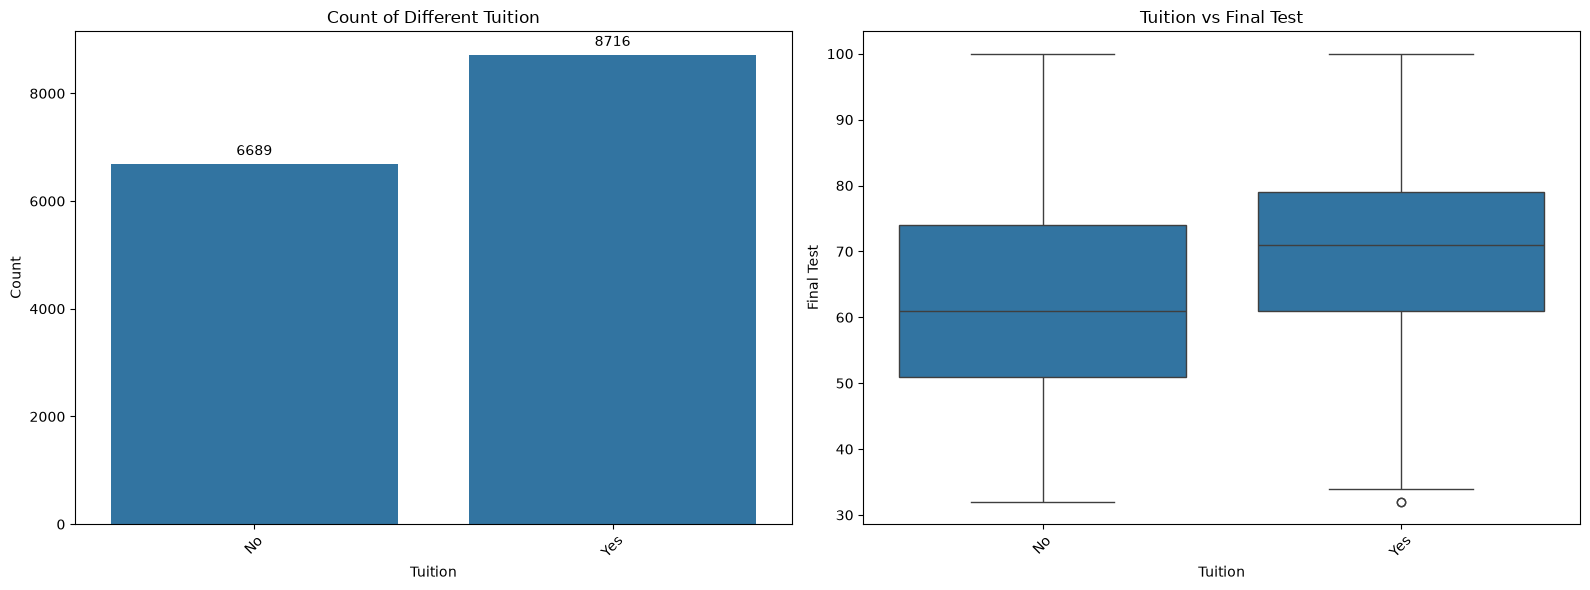

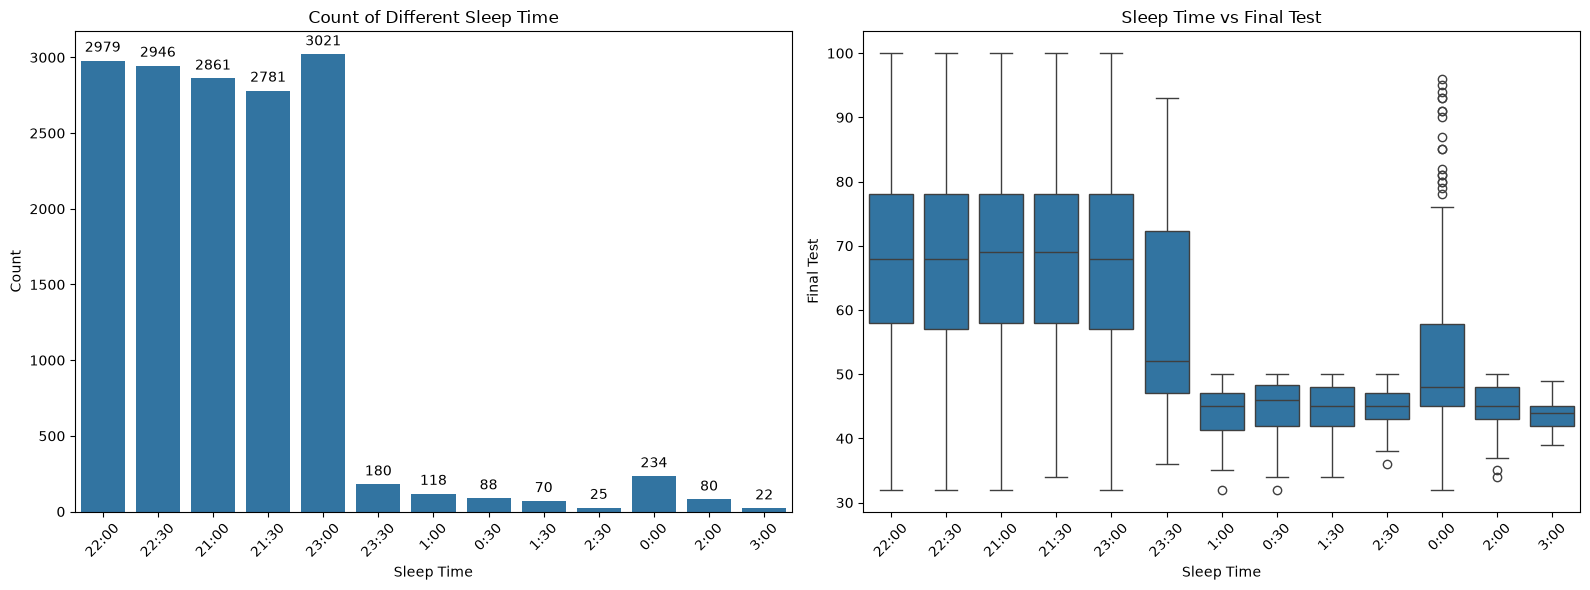

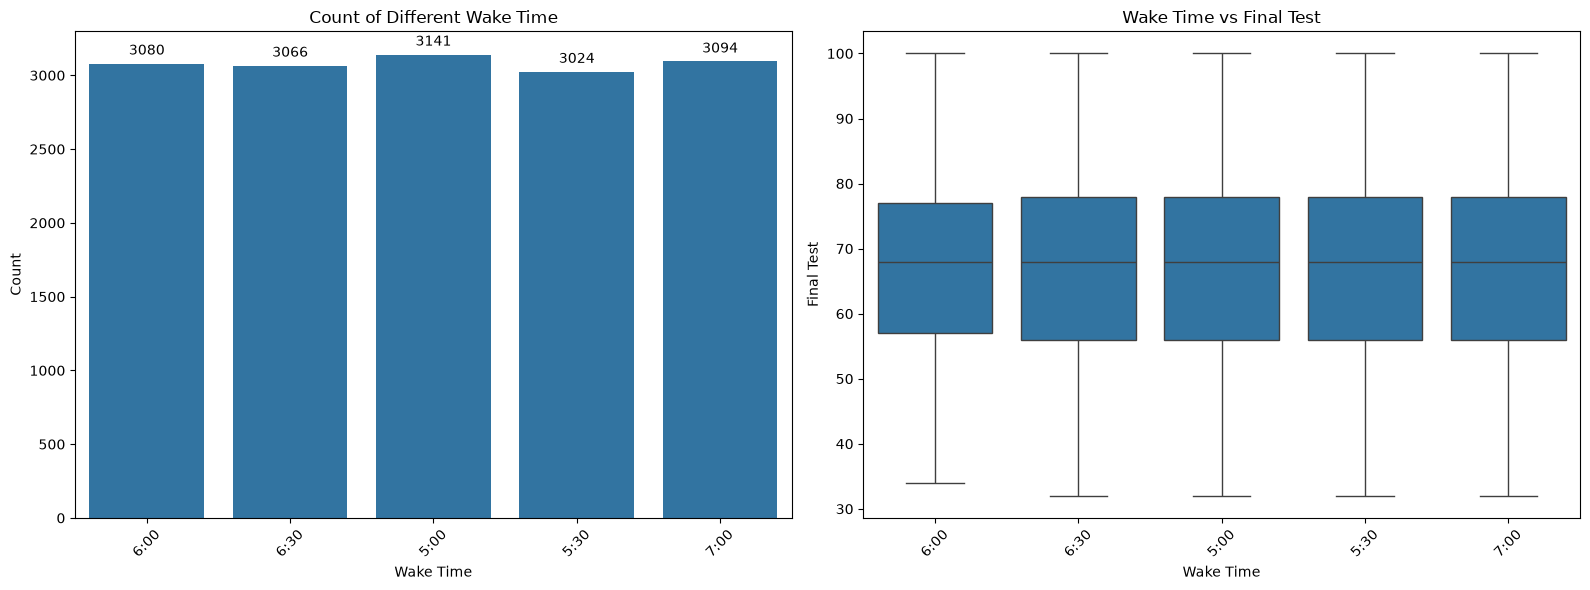

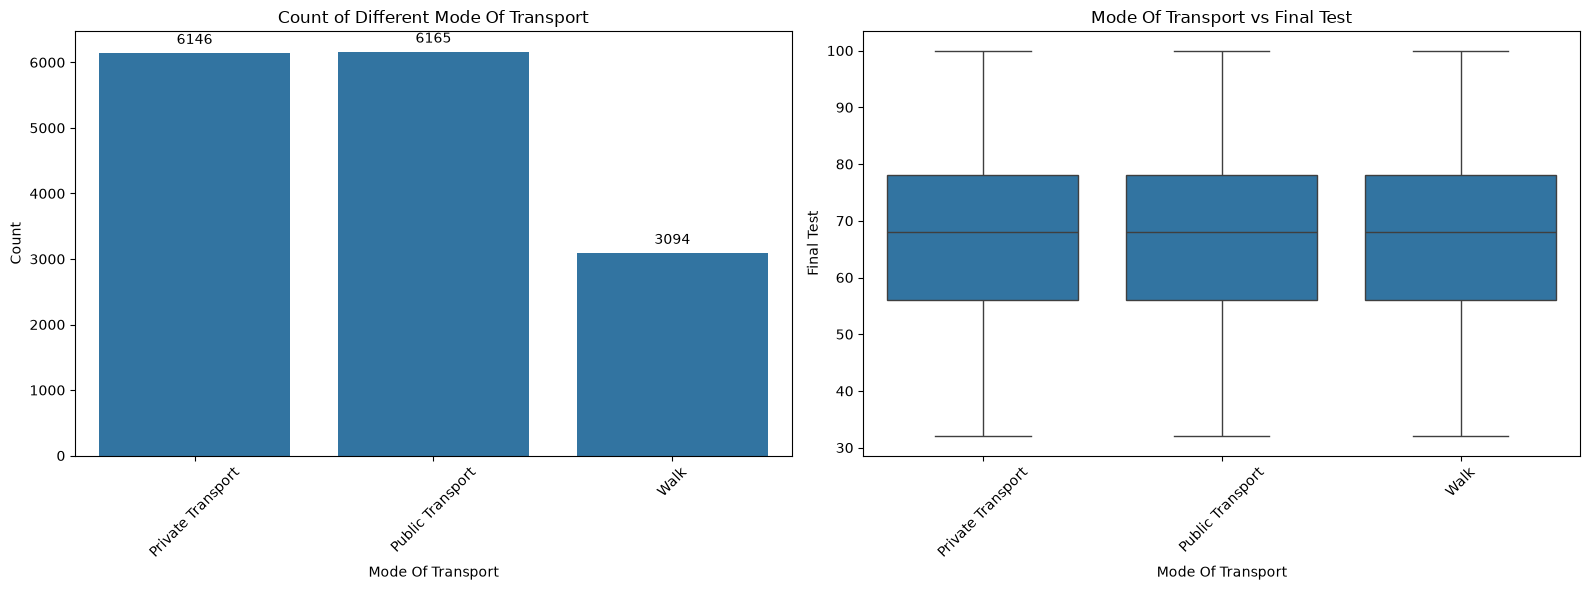

In [18]:
categorical_features = [
    "direct_admission",
    "CCA",
    "learning_style",
    "gender",
    "tuition",
    "sleep_time",
    "wake_time",
    "mode_of_transport",
]

for column in categorical_features:
    df[column] = df[column].astype(str).str.strip().str.title()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Count plot ---
    count_plot = sns.countplot(x=column, data=df, ax=axes[0])
    axes[0].set_title(f"Count of Different {column.replace('_', ' ').title()}")
    axes[0].set_xlabel(column.replace('_', ' ').title())
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=45)
    
    for p in count_plot.patches:
        count_plot.annotate(
            format(p.get_height(), '.0f'),
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 9),
            textcoords='offset points'
        )
    
    # --- Final Test comparison ---
    sns.boxplot(x=column, y="final_test", data=df, ax=axes[1])
    axes[1].set_title(f"{column.replace('_', ' ').title()} vs Final Test")
    axes[1].set_xlabel(column.replace('_', ' ').title())
    axes[1].set_ylabel("Final Test")
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

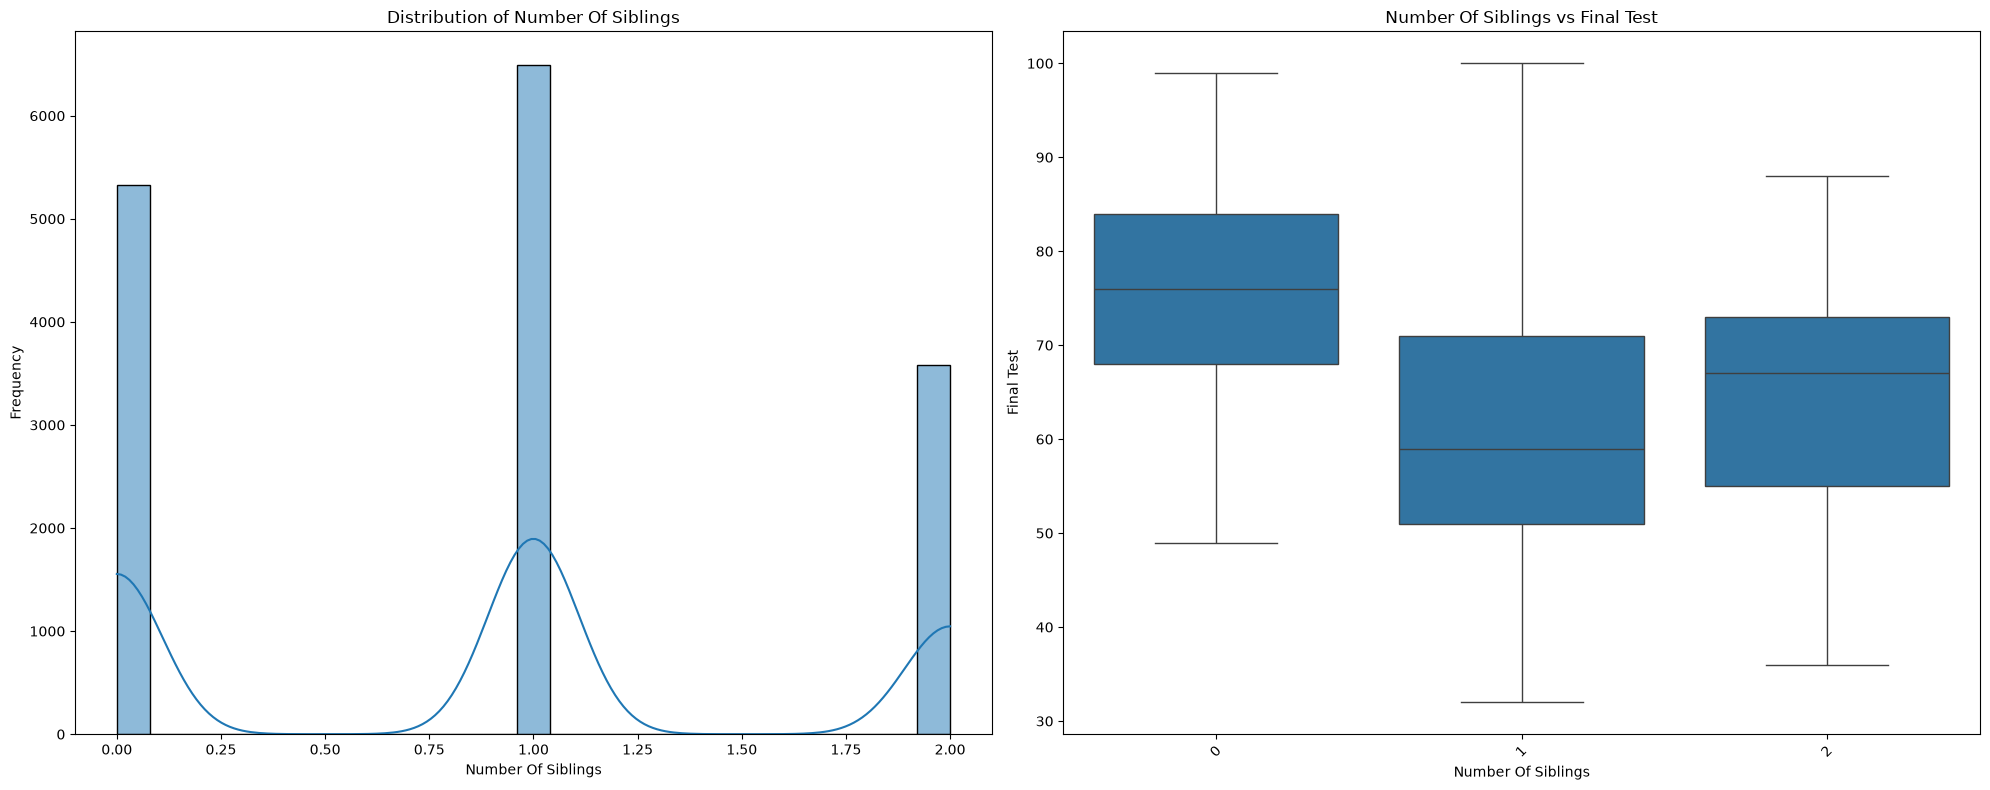

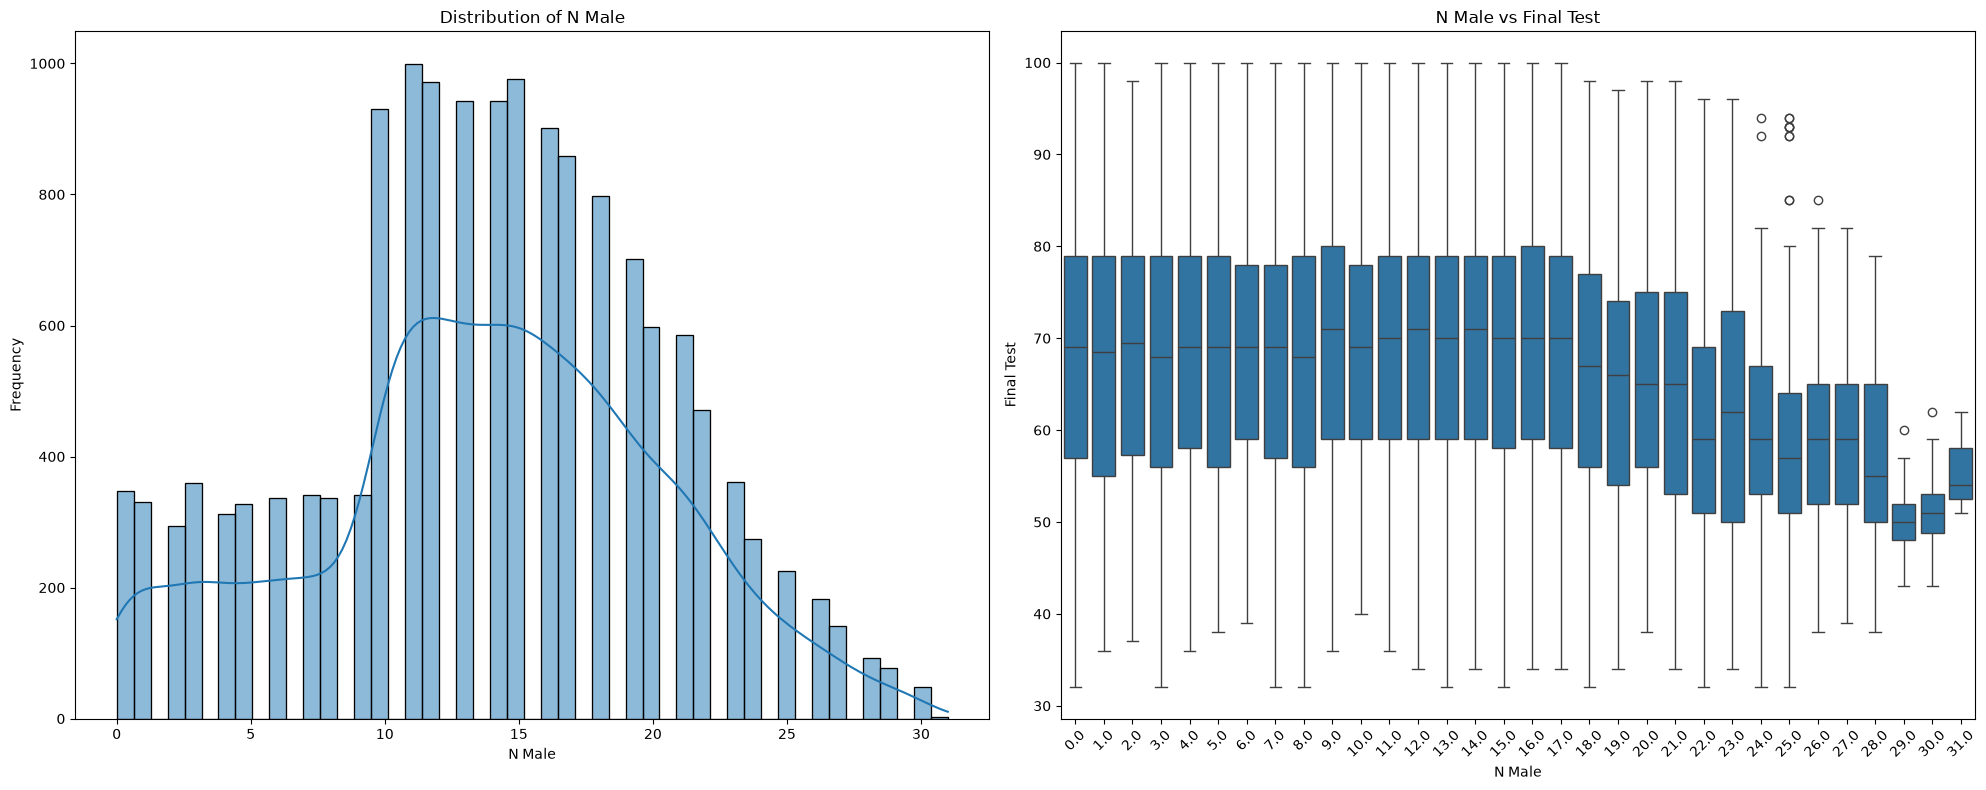

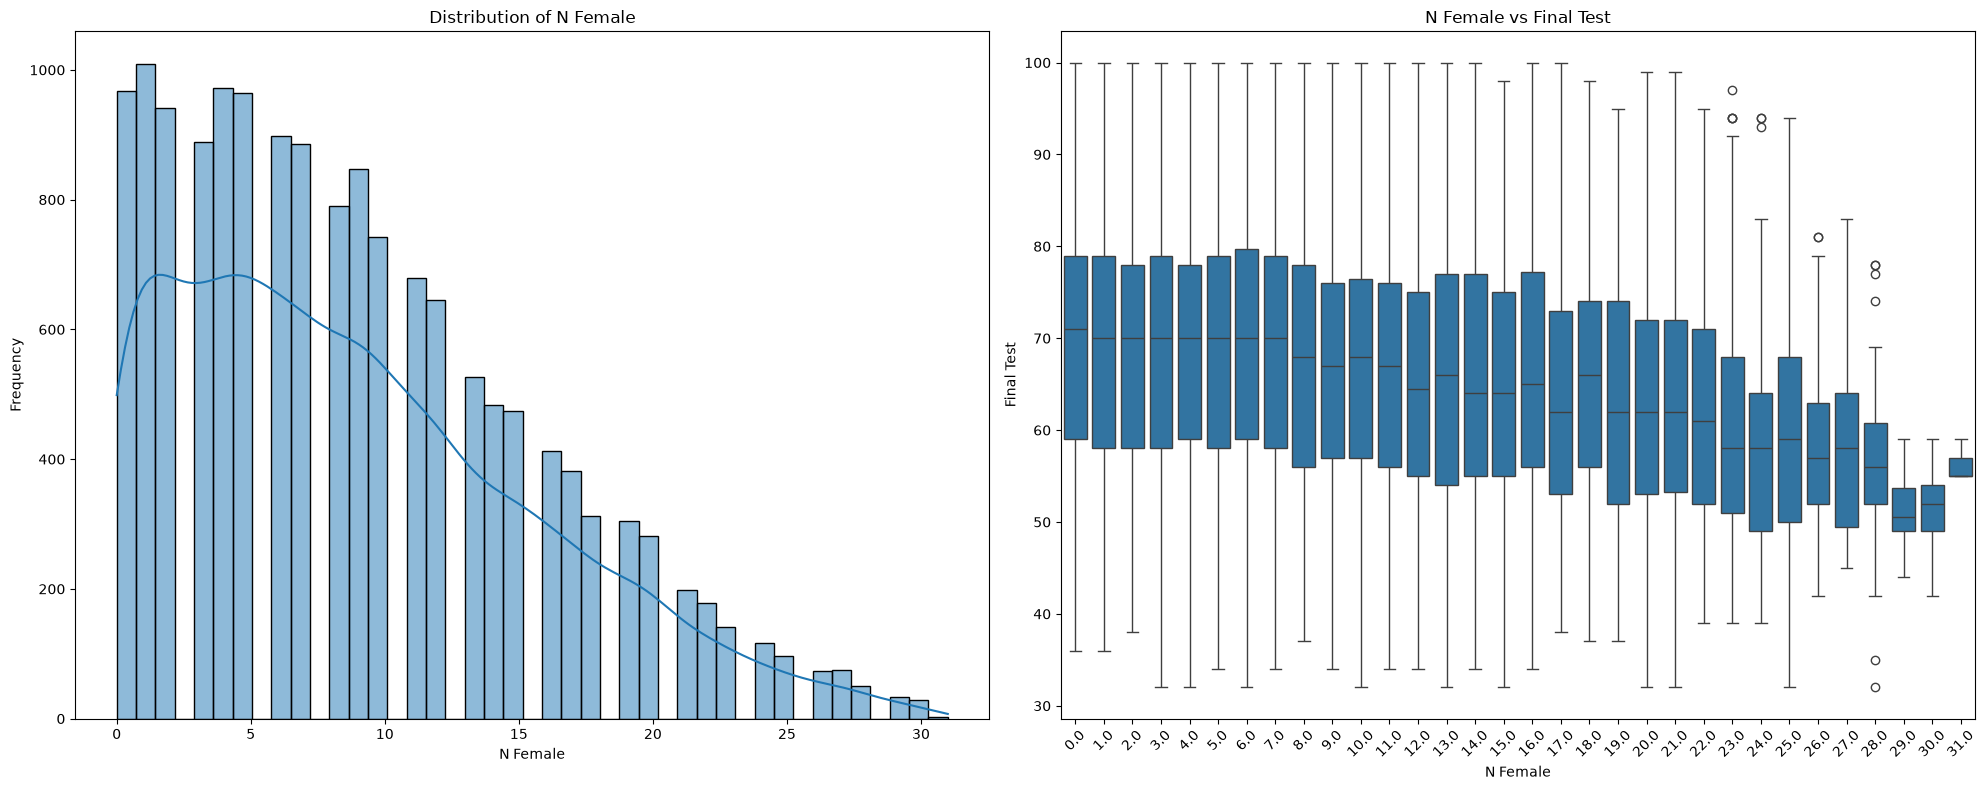

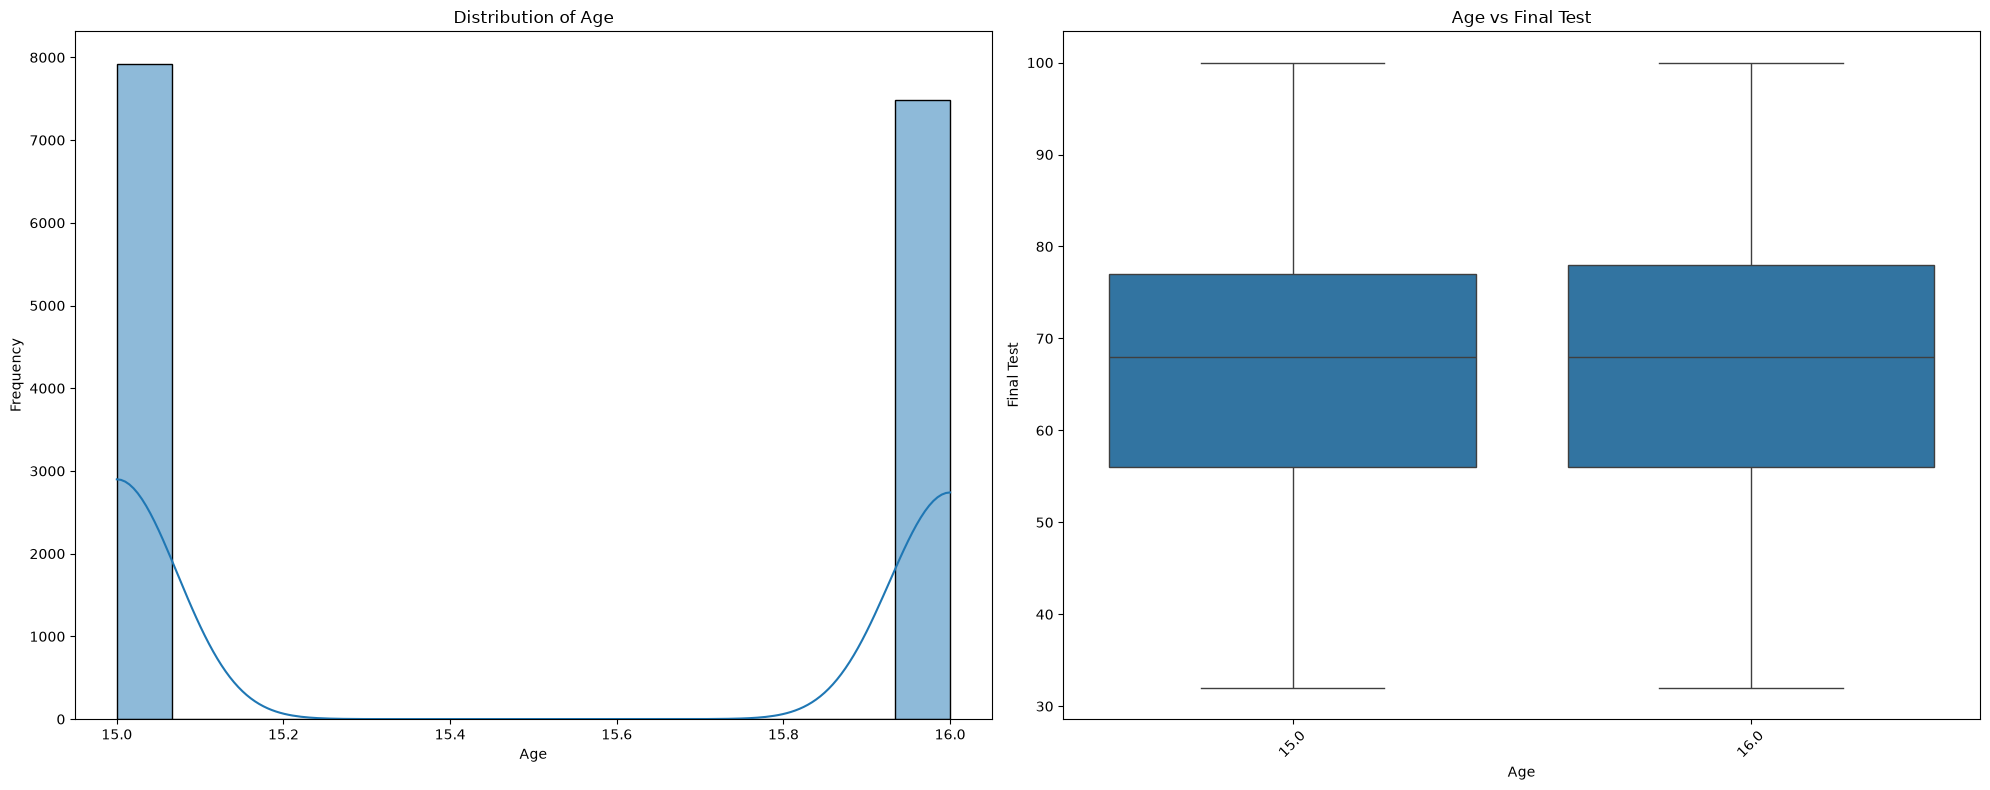

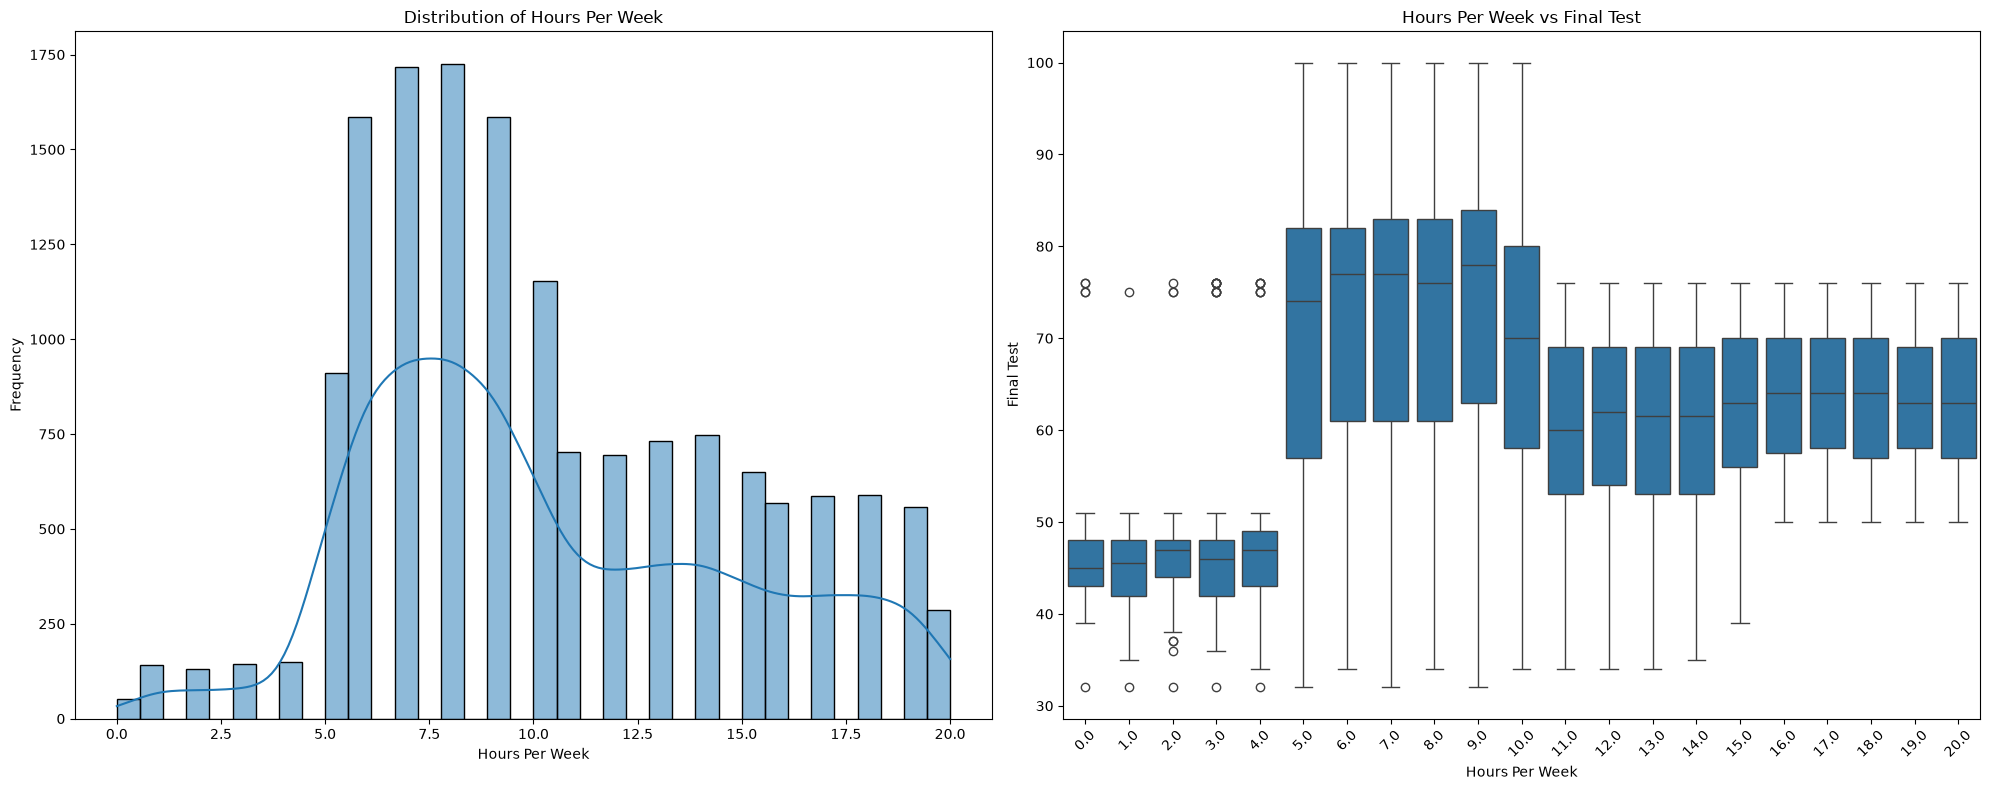

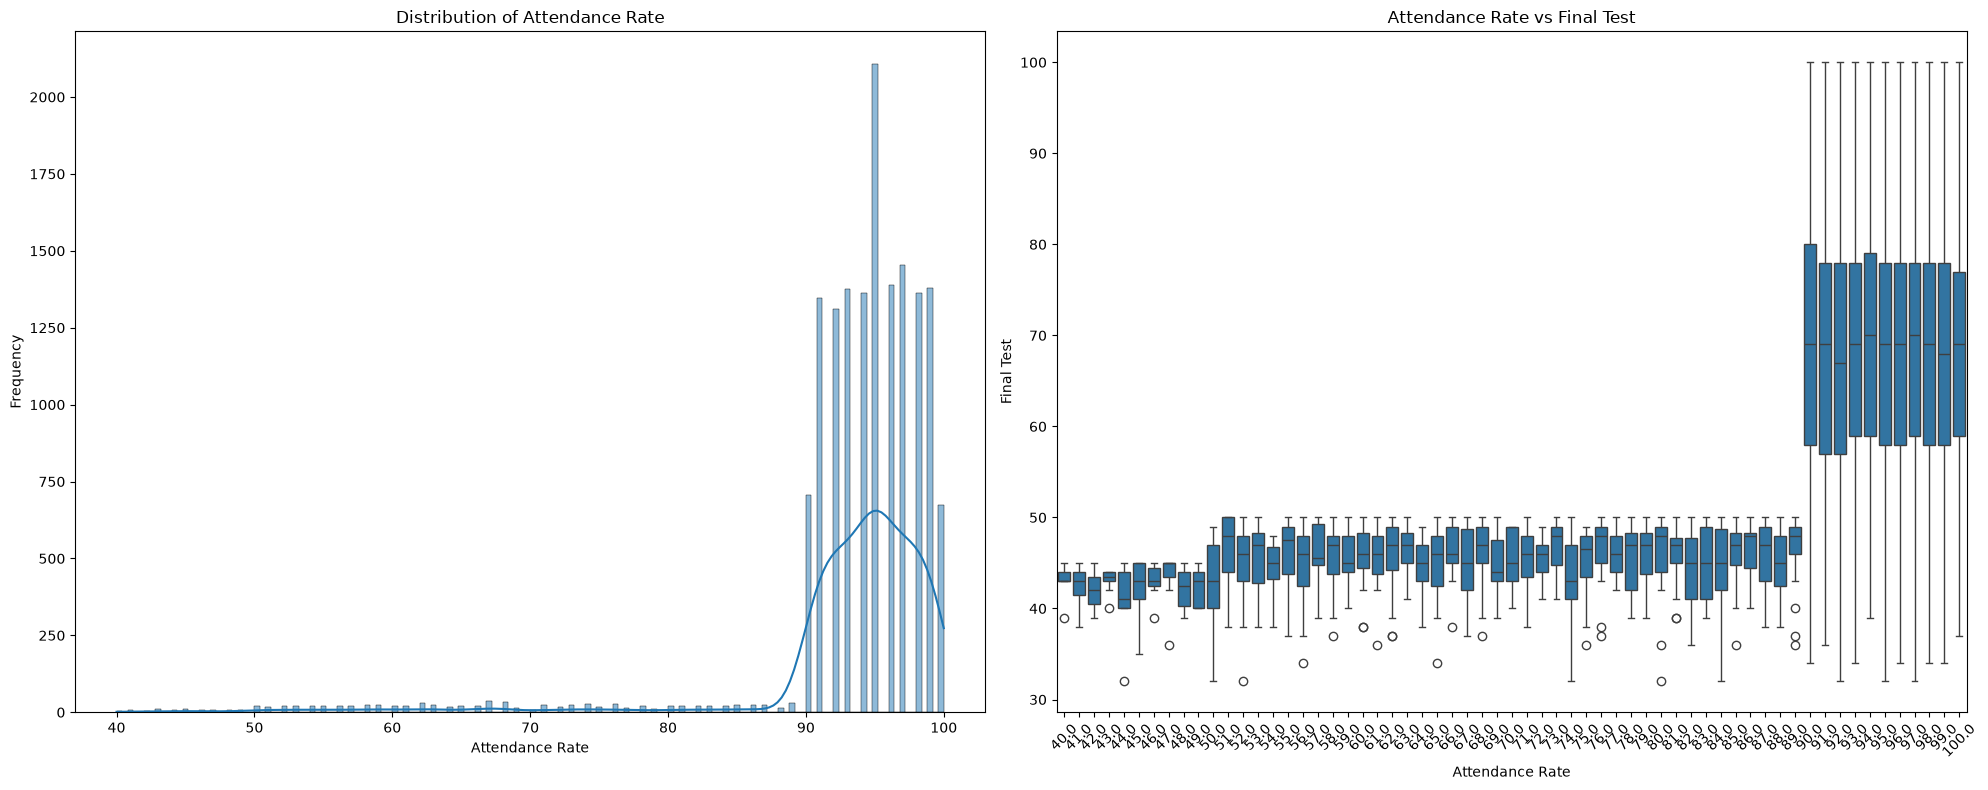

In [19]:
numerical_features = [
    "number_of_siblings",
    "n_male",
    "n_female",
    "age",
    "hours_per_week",
    "attendance_rate",
]

for column in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # --- Distribution plot ---
    sns.histplot(data=df, x=column, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {column.replace('_', ' ').title()}")
    axes[0].set_xlabel(column.replace('_', ' ').title())
    axes[0].set_ylabel("Frequency")
    
    # --- Final Test comparison ---
    sns.boxplot(x=column, y="final_test", data=df, ax=axes[1])
    axes[1].set_title(f"{column.replace('_', ' ').title()} vs Final Test")
    axes[1].set_xlabel(column.replace('_', ' ').title())
    axes[1].set_ylabel("Final Test")
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()